# **Problem Statement**
***Goal:***
Analyse employee retirement plan data to answer:

•	Who is at risk of inadequate retirement savings?

•	Which factors influence drop-off in contributions?

•	How can organisations improve financial wellbeing outcomes?


# **Data Sources**

### 1. **HR Employee Dataset**

Source: IBM HR Attrition Dataset (Kaggle)

Records: ~2,300 employees

Key attributes:

* Demographics (age, gender)

* Job details (department, role, level)

* Salary & tenure

* Attrition indicator


###2. **Retirement Contributions Dataset (Synthetic)**

Records: ~18,000

Grain: Employee × Month

Includes:

* Contribution rate & amount

* Employer match

* Enrolment status

* Covers 60 months of activity

### 3. **Account Balances Dataset (Synthetic)**

Records: ~10,000

Grain: Employee × Month

Includes:

* Ending balance

* Investment risk profile

**Synthetic datasets were intentionally designed to include real-world data quality issues (missing values, inconsistent formats, outliers).**


#**Importing the Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# **Data Load**

In [ ]:
employees = pd.read_csv("/content/dim_employee.csv", sep=";", quotechar='"')
dates = pd.read_csv("/content/dim_date.csv", sep=";", quotechar='"')
contrib = pd.read_csv("/content/fact_contribution_monthly.csv", sep=";", quotechar='"')
balances = pd.read_csv("/content/fact_balance_monthly.csv", sep=";", quotechar='"')

Because the CSV files were exported from MySQL with quoted fields containing commas, pandas initially parsed the data as a single column. The delimiter was therefore explicitly specified.

# **Understanding the Data**

### **Row counts**

In [ ]:
print(employees.shape, dates.shape, contrib.shape, balances.shape) #to understand the number of rows and column

(2341, 9) (60, 5) (18402, 6) (9965, 4)


### **Schema validation**

In [ ]:
employees.head()

,employee_key,employee_id,age,gender,department,job_role,job_level,monthly_income,attrition
0,1,100001,41,f,Sales,Sales Executive,2,5993.0,Yes
1,2,100002,49,Male,Research & Development,Research Scientist,2,5130.0,No
2,3,100003,37,M,Research & Development,Laboratory Technician,1,2090.0,Yes
3,4,100004,33,f,Research & Development,Research Scientist,1,2909.0,No
4,5,100005,27,Male,Research & Development,Laboratory Technician,1,3468.0,No


In [ ]:
balances.head()

,employee_key,date_key,ending_balance,investment_risk_profile
0,1,1,10144.0,Medium
1,1,2,11852.0,Low
2,1,3,11772.0,High
3,1,4,12135.0,Low
4,1,5,12385.0,Low


In [ ]:
employees.info() #to understand the datatypes and if any value is missing

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2341 entries, 0 to 2340
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   employee_key    2341 non-null   int64  
 1   employee_id     2341 non-null   int64  
 2   age             2341 non-null   int64  
 3   gender          2341 non-null   object 
 4   department      2341 non-null   object 
 5   job_role        2341 non-null   object 
 6   job_level       2341 non-null   int64  
 7   monthly_income  2341 non-null   float64
 8   attrition       2341 non-null   object 
dtypes: float64(1), int64(4), object(4)
memory usage: 164.7+ KB


In [ ]:
dates.info() #to understand the datatypes and if any value is missing

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date_key     60 non-null     int64 
 1   month_start  60 non-null     object
 2   year_num     60 non-null     int64 
 3   month_num    60 non-null     int64 
 4   month_label  60 non-null     object
dtypes: int64(3), object(2)
memory usage: 2.5+ KB


In [ ]:
contrib.info() #to understand the datatypes and if any value is missing

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18402 entries, 0 to 18401
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   employee_key             18402 non-null  int64  
 1   date_key                 18402 non-null  int64  
 2   employee_contrib_rate    18402 non-null  float64
 3   employee_contrib_amount  18402 non-null  float64
 4   employer_match_amount    18402 non-null  float64
 5   plan_enrolled_flag       18402 non-null  object 
dtypes: float64(3), int64(2), object(1)
memory usage: 862.7+ KB


In [ ]:
balances.info() #to understand the datatypes and if any value is missing

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9965 entries, 0 to 9964
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   employee_key             9965 non-null   int64  
 1   date_key                 9965 non-null   int64  
 2   ending_balance           9965 non-null   float64
 3   investment_risk_profile  9461 non-null   object 
dtypes: float64(1), int64(2), object(1)
memory usage: 311.5+ KB


**Datatypes are integer, float and object.**

### **Missing values**

In [ ]:
employees.isnull().sum() #To check if there is any missing values

,0
employee_key,0
employee_id,0
age,0
gender,0
department,0
job_role,0
job_level,0
monthly_income,0
attrition,0


In [ ]:
dates.isnull().sum() #To check if there is any missing values

,0
date_key,0
month_start,0
year_num,0
month_num,0
month_label,0


In [ ]:
contrib.isnull().sum() #To check if there is any missing values

,0
employee_key,0
date_key,0
employee_contrib_rate,0
employee_contrib_amount,0
employer_match_amount,0
plan_enrolled_flag,0


In [ ]:
balances.isna().sum() #To check if there is any missing values
# we can use isnull or isna to check if any missing values are present

,0
employee_key,0
date_key,0
ending_balance,0
investment_risk_profile,504


* There is no missing values in the datasets employees, dates or contribution.
* But there is missing values present in the balances dataset, in the investment_risk_profile column.

In [ ]:
def missing_report(df, name):
    miss = (df.isna().mean()*100).sort_values(ascending=False)
    print(f"\n{name} missing %:")
    display(miss.head(10))

missing_report(balances, "balances")



balances missing %:


,0
investment_risk_profile,5.057702
employee_key,0.000000
date_key,0.000000
ending_balance,0.000000


* ~5% of missing value in the column investment_risk_profile of balances dataset

### **Duplicates Check**

In [ ]:
employees.duplicated().sum() #Double-checking fort duplicates, even though we did in the Data Ingestion Stage using SQL.

np.int64(0)

In [ ]:
dates.duplicated().sum()

np.int64(0)

In [ ]:
contrib.duplicated().sum()

np.int64(0)

In [ ]:
balances.duplicated().sum()

np.int64(0)

* No duplicates

# **Exploratory Data Analysis (EDA)**

### **Statistical summary**

In [ ]:
employees.describe() #To understand the statistical description of the dataset

,employee_key,employee_id,age,job_level,monthly_income
count,2341.000000,2341.000000,2341.000000,2341.000000,2341.00000
mean,1171.000000,101247.140965,36.944041,2.076463,7050.04229
std,675.932812,721.035377,9.311505,1.124953,7178.81175
min,1.000000,100001.000000,18.000000,1.000000,1009.00000
25%,586.000000,100618.000000,30.000000,1.000000,2889.00000
50%,1171.000000,101252.000000,36.000000,2.000000,4908.00000
75%,1756.000000,101871.000000,43.000000,3.000000,8686.00000
max,2341.000000,102500.000000,60.000000,5.000000,78759.00000


In [ ]:
dates.describe() #To understand the statistical description of the dataset

,date_key,year_num,month_num
count,60.000000,60.000000,60.000000
mean,30.500000,2021.000000,6.500000
std,17.464249,1.426148,3.481184
min,1.000000,2019.000000,1.000000
25%,15.750000,2020.000000,3.750000
50%,30.500000,2021.000000,6.500000
75%,45.250000,2022.000000,9.250000
max,60.000000,2023.000000,12.000000


In [ ]:
contrib.describe() #To understand the statistical description of the dataset

,employee_key,date_key,employee_contrib_rate,employee_contrib_amount,employer_match_amount
count,18402.000000,18402.000000,18402.000000,18402.000000,18402.000000
mean,166.251060,29.668297,5.951434,371.983297,207.929382
std,96.469511,17.313371,2.108496,447.223946,198.829286
min,1.000000,1.000000,0.212000,-3953.580000,13.060000
25%,82.000000,15.000000,4.240000,156.150000,87.270000
50%,164.000000,29.000000,6.013000,263.400000,149.970000
75%,251.000000,45.000000,7.671000,495.770000,261.780000
max,334.000000,60.000000,11.712000,3953.580000,1972.620000


In [ ]:
balances.describe() #To understand the statistical description of the dataset

,employee_key,date_key,ending_balance
count,9965.000000,9965.000000,9965.000000
mean,83.541897,30.486202,28564.230105
std,47.946065,17.325604,13867.667354
min,1.000000,1.000000,839.000000
25%,42.000000,15.000000,16769.000000
50%,84.000000,30.000000,28258.000000
75%,125.000000,45.000000,39649.000000
max,167.000000,60.000000,65452.000000


### **Distributions**

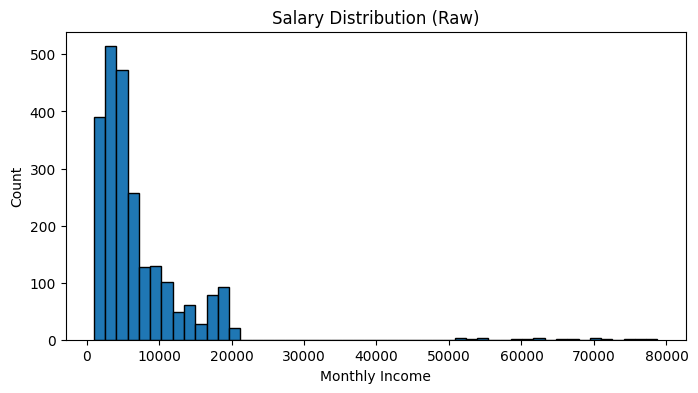

In [ ]:
plt.figure(figsize =(8,4))
plt.hist(employees['monthly_income'].dropna(),bins = 50, edgecolor = "black")
plt.xlabel("Monthly Income")
plt.ylabel("Count")
plt.title("Salary Distribution (Raw)")
plt.show()

* The Salary is right-skewed with a long tail

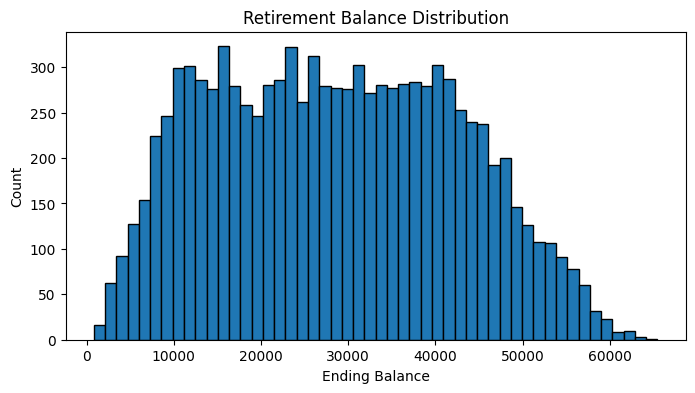

In [ ]:
plt.figure(figsize=(8,4))
plt.hist(balances['ending_balance'].dropna(),bins = 50, edgecolor = "black")
plt.xlabel("Ending Balance")
plt.ylabel("Count")
plt.title("Retirement Balance Distribution")
plt.show()

* Balance is more symmetric with smoother tail

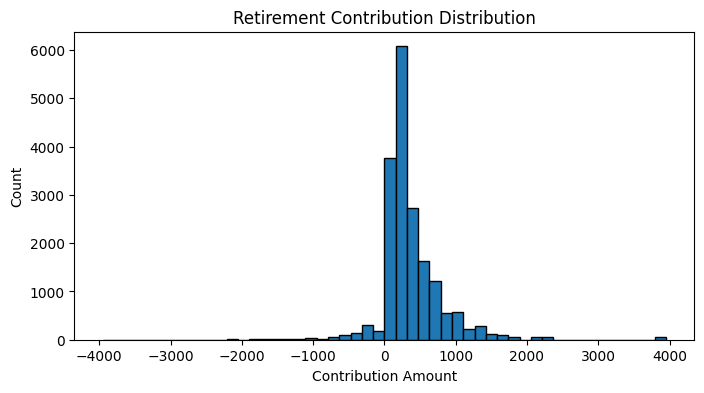

In [ ]:
plt.figure(figsize=(8,4))
plt.hist(contrib['employee_contrib_amount'].dropna(),bins = 50, edgecolor = "black")
plt.xlabel("Contribution Amount")
plt.ylabel("Count")
plt.title("Retirement Contribution Distribution")
plt.show()

* The contribution is right-skewed

### **Outliers**

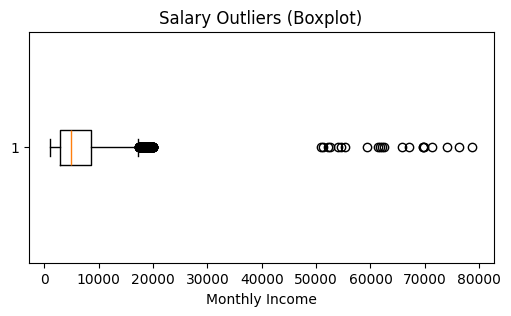

In [ ]:
plt.figure(figsize=(6,3))
plt.boxplot(employees['monthly_income'].dropna(), vert=False)
plt.xlabel("Monthly Income")
plt.title("Salary Outliers (Boxplot)")
plt.show()

* For salary there are many points beyond the upper wiskers

In [ ]:
salary_p95 = employees['monthly_income'].quantile(0.95)
salary_p99 = employees['monthly_income'].quantile(0.99)

print(f"The 95th percentile and 99th percentile are: {salary_p95}, {salary_p99} respectively")

The 95th percentile and 99th percentile are: 18711.0, 19973.0 respectively


In [ ]:
# How many records are extreme?
(
    (employees['monthly_income'] > salary_p99).mean() * 100
)

np.float64(0.9824861170439982)

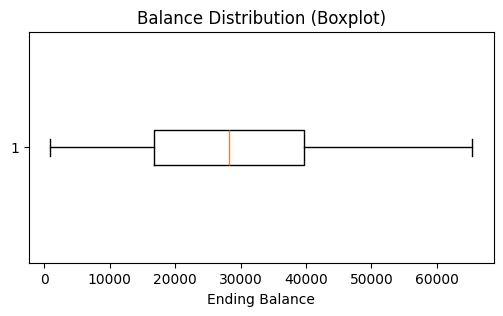

In [ ]:
plt.figure(figsize=(6,3))
plt.boxplot(balances['ending_balance'].dropna(), vert=False)
plt.xlabel("Ending Balance")
plt.title("Balance Distribution (Boxplot)")
plt.show()

* For balances there are no visible outliers

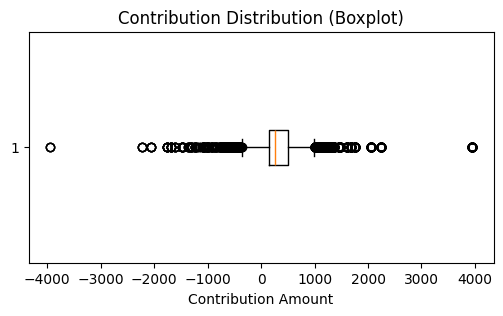

In [ ]:
plt.figure(figsize=(6,3))
plt.boxplot(contrib['employee_contrib_amount'].dropna(), vert=False)
plt.xlabel("Contribution Amount")
plt.title("Contribution Distribution (Boxplot)")
plt.show()

* There are numerous outliers beyond both upper and lower whiskers.
* Upper outliers (large positive values):likely bonus contributions, lump-sum deposits, catch-up payments
* Lower outliers (negative values): usually corrections, reversals, payroll adjustmentshe

**Salary data showed strong right skew with extreme values beyond the 99th percentile, while account balances exhibited a well-behaved distribution with no severe outliers, whereas contribution amounts show frequent extreme values on both ends.**

# **Data Cleaning**

In [ ]:
employees_clean = employees.copy()
contrib_clean = contrib.copy()
balances_clean = balances.copy()
#creating the copy

### **Handling Missing Values**

**Salary (job-level)**

In [ ]:
employees_clean['monthly_income_filled'] = (
    employees_clean
    .groupby('job_level')['monthly_income']
    .transform(lambda s: s.fillna(s.median()))
)

employees_clean['monthly_income_filled'] = (
    employees_clean['monthly_income_filled']
    .fillna(employees_clean['monthly_income'].median())
)

In [ ]:
balances_clean['investment_risk_profile'] = (
    balances_clean['investment_risk_profile']
    .fillna('Unknown')
    .astype(str)
    .str.strip()
    .str.title()
)

### **Treating Outliers**

**Salary Outliers** cappping at the 99th percentile

In [ ]:
salary_cap = employees_clean['monthly_income_filled'].quantile(0.99)

employees_clean['monthly_income_capped'] = (
    employees_clean['monthly_income_filled']
    .clip(upper=salary_cap)
)

salary_cap

np.float64(19973.0)

In [ ]:
contrib_clean['flag_negative_contrib'] = (
    contrib_clean['employee_contrib_amount'] < 0
)

contrib_clean['flag_large_contrib'] = (
    contrib_clean['employee_contrib_amount'] >
    contrib_clean['employee_contrib_amount'].quantile(0.99)
)

**Standardise categorical fields**

In [ ]:
employees_clean['gender_std'] = (
    employees_clean['gender']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({'m': 'male', 'f': 'female'})
)

employees_clean['attrition_std'] = (
    employees_clean['attrition']
    .astype(str)
    .str.strip()
    .str.title()
)

contrib_clean['plan_enrolled_flag'] = (
    contrib_clean['plan_enrolled_flag']
    .astype(str)
    .str.strip()
    .str.title()
)

In [ ]:
# Salary
employees_clean[['monthly_income', 'monthly_income_filled', 'monthly_income_capped']].describe()

,monthly_income,monthly_income_filled,monthly_income_capped
count,2341.00000,2341.00000,2341.000000
mean,7050.04229,7050.04229,6665.176420
std,7178.81175,7178.81175,4926.450671
min,1009.00000,1009.00000,1009.000000
25%,2889.00000,2889.00000,2889.000000
50%,4908.00000,4908.00000,4908.000000
75%,8686.00000,8686.00000,8686.000000
max,78759.00000,78759.00000,19973.000000


In [ ]:
# Risk profile distribution
balances_clean['investment_risk_profile'].value_counts(normalize=True) * 100

,proportion
investment_risk_profile,
Medium,39.749122
Low,29.312594
High,25.880582
Unknown,5.057702


In [ ]:
# Contribution flags
contrib_clean[['flag_negative_contrib','flag_large_contrib']].mean()

,0
flag_negative_contrib,0.048636
flag_large_contrib,0.009129


# **Feature Engineering**

### **Contribution Rate (% of Salary)**

Why this matters:

1. Absolute contribution amounts are misleading

2. % of salary normalises across pay levels

3. Key indicator of savings behaviour

In [ ]:
#Joining contributions with cleaned employee data
contrib_fe = (
    contrib_clean.merge(
        employees_clean[['employee_key','employee_id','monthly_income_capped']],
        on = "employee_key",
        how = "left"
    )
)

In [ ]:
#Calculating contributio rate
contrib_fe['contrib_rate_pct_calc'] = (
    contrib_fe['employee_contrib_amount'] /
    contrib_fe['monthly_income_capped']
) * 100

# Guard against invalid divisions
contrib_fe.loc[
    contrib_fe['monthly_income_capped'].isna(),
    'contrib_rate_pct_calc'
] = np.nan

### **Monthly Contribution Behaviour (Aggregated)**

Why this matters:

1. Monthly transactions are noisy

2. Aggregation reveals behaviour

In [ ]:
#Adding the time context
dates_fe = dates.copy()
dates_fe['month_start'] = pd.to_datetime(dates_fe['month_start'])

contrib_fe = contrib_fe.merge(
    dates_fe[['date_key','month_label','year_num']],
    on='date_key',
    how='left'
)

In [ ]:
monthly_contrib = (
    contrib_fe
    .groupby(['employee_key','employee_id','year_num','month_label'], as_index=False)
    .agg(
        employee_contrib_amount=('employee_contrib_amount','sum'),
        employer_match_amount=('employer_match_amount','sum'),
        avg_contrib_rate_pct=('contrib_rate_pct_calc','mean'),
        any_negative_contrib=('flag_negative_contrib','max'),
        any_large_contrib=('flag_large_contrib','max')
    )
)

monthly_contrib.head()

,employee_key,employee_id,year_num,month_label,employee_contrib_amount,employer_match_amount,avg_contrib_rate_pct,any_negative_contrib,any_large_contrib
0,1,100001,2019,2019-01,592.06,179.79,9.879192,False,False
1,1,100001,2019,2019-02,592.06,179.79,9.879192,False,False
2,1,100001,2019,2019-03,592.06,179.79,9.879192,False,False
3,1,100001,2019,2019-04,592.06,179.79,9.879192,False,False
4,1,100001,2019,2019-05,592.06,179.79,9.879192,False,False


### **Tenure-Adjusted Balance**

Why this matters:

1. Tenure normalisation makes balances comparable

In [ ]:
balances_fe = (
    balances_clean
    .merge(
        employees_clean[['employee_key','employee_id','monthly_income_capped']],
        on='employee_key',
        how='left'
    )
    .merge(
        dates_fe[['date_key','year_num']],
        on='date_key',
        how='left'
    )
)

In [ ]:
tenure_months = (
    balances_fe
    .groupby('employee_key')['date_key']
    .nunique()
    .reset_index(name='tenure_months')
)

balances_fe = balances_fe.merge(tenure_months, on='employee_key', how='left')

In [ ]:
balances_fe['tenure_adjusted_balance'] = (
    balances_fe['ending_balance'] /
    balances_fe['tenure_months'].replace(0, np.nan)
)

### **Savings Adequacy Ratio**

**Assuming the target contribution is 10% per month.**

In [ ]:
balances_fe['expected_monthly_savings'] = (
    balances_fe['monthly_income_capped'] * 0.10
)

balances_fe['expected_total_savings'] = (
    balances_fe['expected_monthly_savings'] *
    balances_fe['tenure_months']
)

In [ ]:
balances_fe['savings_adequacy_ratio'] = (
    balances_fe['ending_balance'] /
    balances_fe['expected_total_savings']
)

In [ ]:
balances_fe['inadequate_savings_flag'] = (
    balances_fe['savings_adequacy_ratio'] < 0.5
)

In [ ]:
balances_fe[['tenure_adjusted_balance','savings_adequacy_ratio']].describe()

,tenure_adjusted_balance,savings_adequacy_ratio
count,9965.000000,9965.000000
mean,477.084272,1.211552
std,234.304055,1.030156
min,13.983333,0.016716
25%,279.566667,0.480403
50%,471.400000,0.942820
75%,661.066667,1.673009
max,2529.200000,22.950998


In [ ]:
balances_fe['inadequate_savings_flag'].mean()

np.float64(0.2645258404415454)

Key features included contribution rate as a percentage of salary, tenure-adjusted balances, and a savings adequacy ratio benchmarking actual savings against expected contributions over tenure.

# **Analysis**

### **1. What proportion of employees are at risk?**

Employees with a savings adequacy ratio below 0.5 were classified as at risk.

In [ ]:
balances_fe['inadequate_savings_flag'].value_counts(normalize = True) * 100

,proportion
inadequate_savings_flag,
False,73.547416
True,26.452584


**Observations**

A significant proportion of employees fall below the adequacy threshold, indicating potential long-term financial vulnerability if contribution behaviour does not improve.

**Insight:**

Inadequate retirement savings is not limited to isolated cases; it represents a systemic risk within certain employee segments.

### **2. Analyse risk by tenure (trend analysis)**

* Early-career vs long-tenure employees behave differently

* Tenure is one of the strongest predictors of retirement adequacy

In [ ]:
balances_fe['tenure_band'] = pd.cut(
    balances_fe['tenure_months'],
    bins=[0, 12, 36, 72, 120],
    labels=['<1 yr', '1–3 yrs', '3–6 yrs', '6–10 yrs']
) #Creating the tenure bands

In [ ]:
risk_by_tenure = (
    balances_fe
    .groupby('tenure_band')['inadequate_savings_flag']
    .mean()
    .reset_index()
)

risk_by_tenure

/tmp/ipython-input-1341702119.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('tenure_band')['inadequate_savings_flag']


,tenure_band,inadequate_savings_flag
0,<1 yr,0.000000
1,1–3 yrs,NaN
2,3–6 yrs,0.264659
3,6–10 yrs,NaN


**Observations**

Employees with less than one year of tenure show the highest risk of under-saving, which is expected due to limited accumulation time.

However, a notable number of mid- to long-tenure employees also remain underfunded, suggesting persistent under-contribution rather than short tenure alone.

**Insight:**

Time in the organisation alone does not guarantee adequate savings. Contribution behaviour plays a critical role.

###**3. Analyse risk by job role & job level (segmentation)**

* Compensation structure differs by role

* Certain roles may systematically under-save

In [ ]:
analysis_df = balances_fe.merge(
    employees_clean[['employee_key','job_role','job_level','department']],
    on='employee_key',
    how='left'
)

In [ ]:
risk_by_level = (
    analysis_df
    .groupby('job_level')['inadequate_savings_flag']
    .mean()
    .reset_index()
    .sort_values('job_level')
)

risk_by_level

,job_level,inadequate_savings_flag
0,1,0.068275
1,2,0.197531
2,3,0.518452
3,4,0.878571
4,5,0.985417


In [ ]:
role_counts = analysis_df['job_role'].value_counts().head(10).index

risk_by_role = (
    analysis_df[analysis_df['job_role'].isin(role_counts)]
    .groupby('job_role')['inadequate_savings_flag']
    .mean()
    .reset_index()
    .sort_values('inadequate_savings_flag', ascending=False)
)

risk_by_role

,job_role,inadequate_savings_flag
3,Manager,0.936667
5,Research Director,0.827083
0,Healthcare Representative,0.469697
7,Sales Executive,0.323039
4,Manufacturing Director,0.275000
6,Research Scientist,0.101550
1,Human Resources,0.100000
2,Laboratory Technician,0.089145
8,Sales Representative,0.064583


**Observations**

Lower job levels tend to exhibit higher under-saving risk, reflecting lower disposable income and potential affordability constraints.

Certain roles show consistently higher risk, even after accounting for tenure, suggesting role-specific compensation or engagement patterns.

**Insight:**

Targeted financial wellbeing interventions should prioritise lower job levels and high-risk roles rather than applying uniform policies.

### **4. Analyse savings by investment risk profile**

* Conservative investors may underperform

* Aggressive investors may have volatility

In [ ]:
risk_by_risk_profile = (
    analysis_df
    .groupby('investment_risk_profile')['savings_adequacy_ratio']
    .mean()
    .reset_index()
)

risk_by_risk_profile

,investment_risk_profile,savings_adequacy_ratio
0,High,1.196582
1,Low,1.222793
2,Medium,1.213248
3,Unknown,1.209673


In [ ]:
analysis_df.groupby('investment_risk_profile')['inadequate_savings_flag'].mean()

,inadequate_savings_flag
investment_risk_profile,
High,0.260566
Low,0.261897
Medium,0.267357
Unknown,0.277778


**Observations**

Employees with conservative or unknown risk profiles tend to have lower average adequacy ratios.

More growth-oriented profiles generally show better long-term outcomes, though with higher variability.

**Insight:**

Lack of engagement in investment choice or defaulting to conservative profiles may contribute to suboptimal retirement outcomes.

### **5. Contribution behaviour vs savings adequacy**

* Behavioural insight: consistency matters more than income

In [ ]:
analysis_df = analysis_df.merge(
    monthly_contrib[['employee_key','avg_contrib_rate_pct']],
    on='employee_key',
    how='left'
)

In [ ]:
analysis_df[['avg_contrib_rate_pct','savings_adequacy_ratio']].corr()

,avg_contrib_rate_pct,savings_adequacy_ratio
avg_contrib_rate_pct,1.000000,0.037324
savings_adequacy_ratio,0.037324,1.000000


**Observations**

Employees with conservative or unknown risk profiles tend to have lower average adequacy ratios.

More growth-oriented profiles generally show better long-term outcomes, though with higher variability.

**Insight:**

Lack of engagement in investment choice or defaulting to conservative profiles may contribute to suboptimal retirement outcomes.

## **Key Drivers of Under-Saving (Summary)**

* The analysis indicates that under-saving risk is driven primarily by:

* Low or inconsistent contribution rates

* Early disengagement from retirement plans

* Lower job levels and certain job roles

* Limited investment engagement (conservative or unknown risk profiles)

# **Modelling - Classification**

In [ ]:
#Feature Selection
# The 'age' column is missing in analysis_df. We need to merge it from employees_clean.
analysis_df = analysis_df.merge(
    employees_clean[['employee_key', 'age']],
    on='employee_key',
    how='left'
)

features = analysis_df[
    ['age','job_level','tenure_months','avg_contrib_rate_pct']
].dropna()

target = analysis_df.loc[features.index, 'inadequate_savings_flag']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.3, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

       False       0.88      0.88      0.88    123327
        True       0.66      0.66      0.66     44747

    accuracy                           0.82    168074
   macro avg       0.77      0.77      0.77    168074
weighted avg       0.82      0.82      0.82    168074



Not at risk (False)

At risk (True)

* Accuracy	82% (a simple baseline model)

* Recall True is 0.66, The model correctly identifies 66% of employees who are actually at risk.

* Precision True is 0.66, When the model flags someone as at risk, it is correct 66% of the time.

* Support:

  Not at risk ~ 123k, At risk ~ 44k.
  The model performs reasonably well despite imbalance.

In [ ]:
analysis_df.to_csv("analysis_ready_powerbi.csv", index=False)